In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
transactions = pd.read_csv("../data/processed/clean_transactions.csv")

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [3]:
print("Rows :", transactions.shape[0])
print("Columns :", transactions.shape[1])

transactions.info()

Rows : 32778
Columns : 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  object        
 1   transaction_date    32778 non-null  datetime64[ns]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  object        
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  object        
 6   city                32778 non-null  object        
 7   city_tier           32778 non-null  object        
 8   age_group           32778 non-null  object        
 9   gender              32778 non-null  object        
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  object        
 12  kyc_status          32778 non-null  object        
dtypes: datetime64[ns](1)

In [4]:
transactions.describe(include="all")

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
count,32778,32778,32778.000000,32778,32778.000000,32778,32778,32778,32778,32778,32778.000000,32778,32778
unique,5000,NaN,NaN,3,NaN,12,24,2,5,2,NaN,4,2
top,INV001497,NaN,NaN,SIP,NaN,Punjab,Kolkata,T30,26-35,Male,NaN,Net Banking,Verified
freq,12,NaN,NaN,19716,NaN,2965,2748,21719,13463,21809,NaN,8250,30146
mean,NaN,2024-09-14 09:53:02.207578112,120264.617518,NaN,107437.318628,NaN,NaN,NaN,NaN,NaN,26.181219,NaN,NaN
min,NaN,2024-01-01 00:00:00,100016.000000,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN
25%,NaN,2024-05-08 00:00:00,118632.000000,NaN,3153.000000,NaN,NaN,NaN,NaN,NaN,10.600000,NaN,NaN
50%,NaN,2024-09-14 00:00:00,119551.000000,NaN,17782.500000,NaN,NaN,NaN,NaN,NaN,19.700000,NaN,NaN
75%,NaN,2025-01-21 00:00:00,120843.000000,NaN,189324.250000,NaN,NaN,NaN,NaN,NaN,37.400000,NaN,NaN
max,NaN,2025-05-30 00:00:00,149324.000000,NaN,597498.000000,NaN,NaN,NaN,NaN,NaN,99.700000,NaN,NaN


In [5]:
transactions["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

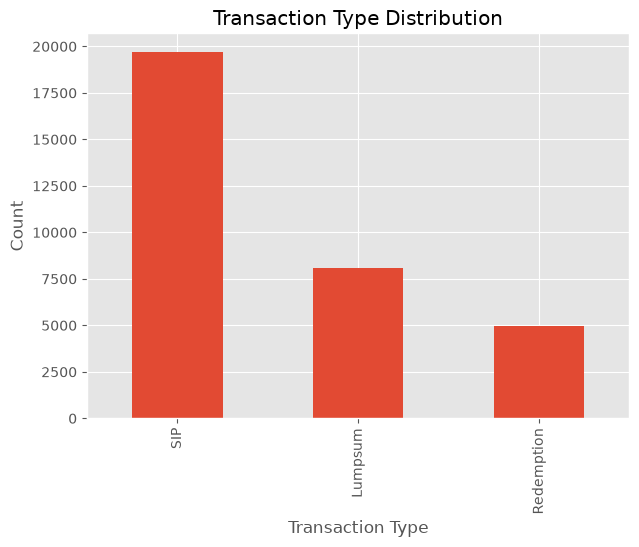

In [6]:
transactions["transaction_type"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

In [7]:
print("Total Investment : ₹{:,.2f}".format(
    transactions["amount_inr"].sum()
))

Total Investment : ₹3,521,580,430.00


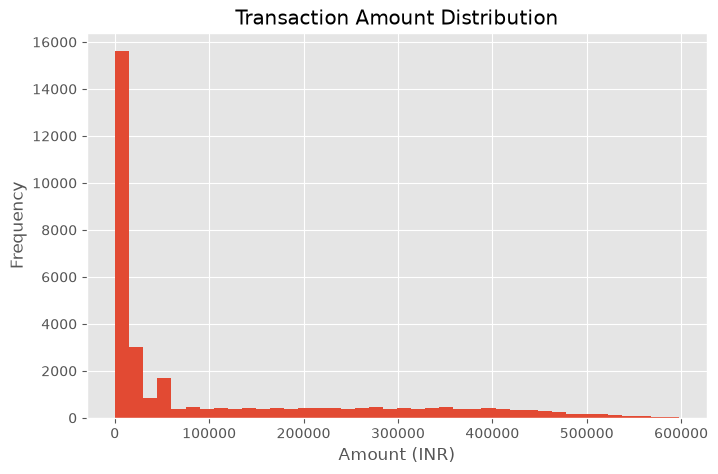

In [8]:
plt.figure(figsize=(8,5))

plt.hist(transactions["amount_inr"], bins=40)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")

plt.show()

In [9]:
top_states = (
    transactions["state"]
    .value_counts()
    .head(10)
)

top_states

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Name: count, dtype: int64

In [10]:
transactions["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

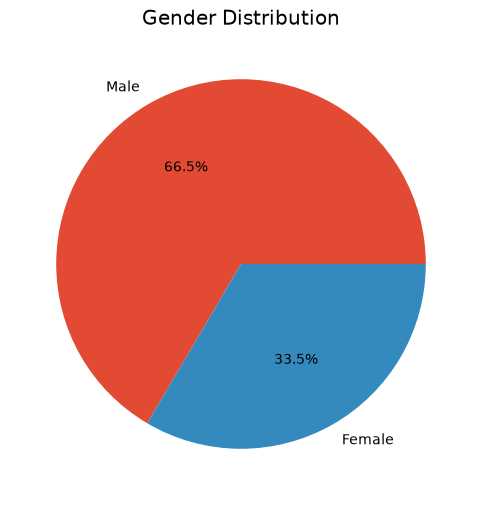

In [11]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Gender Distribution")

plt.show()

In [12]:
transactions["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

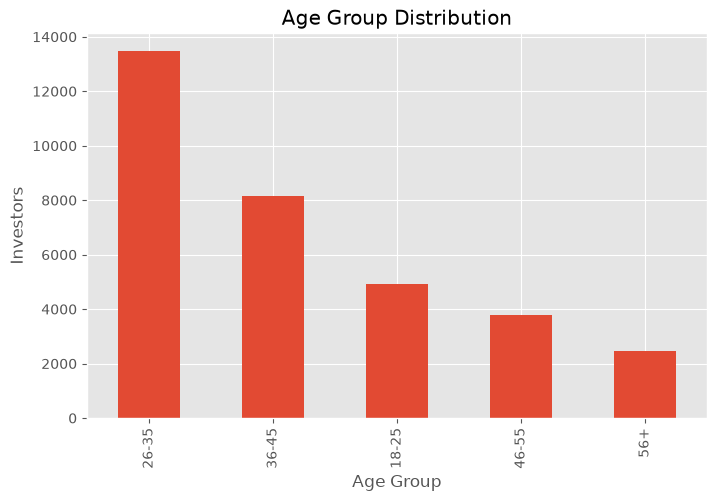

In [13]:
transactions["age_group"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Investors")

plt.show()

In [14]:
transactions["payment_mode"].value_counts()

payment_mode
Net Banking    8250
Cheque         8228
UPI            8154
Mandate        8146
Name: count, dtype: int64

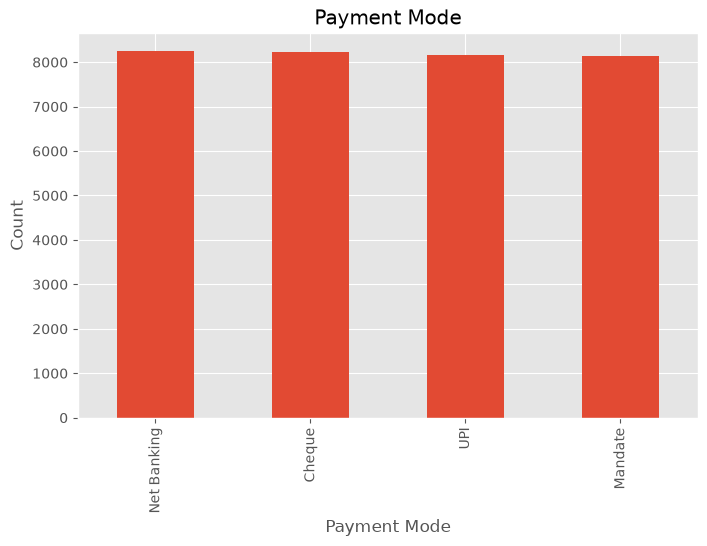

In [15]:
transactions["payment_mode"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Count")

plt.show()

In [16]:
transactions["kyc_status"].value_counts()

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

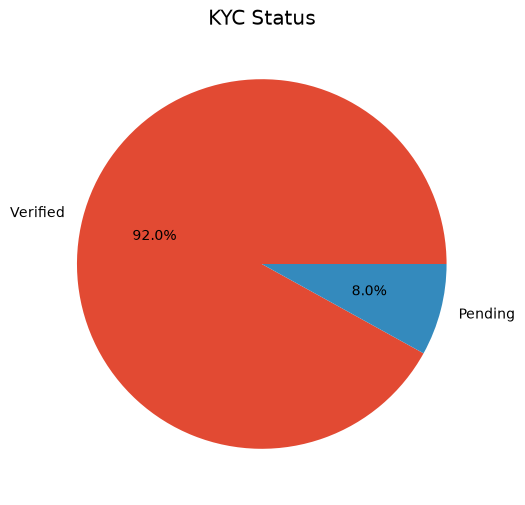

In [17]:
transactions["kyc_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("KYC Status")

plt.show()

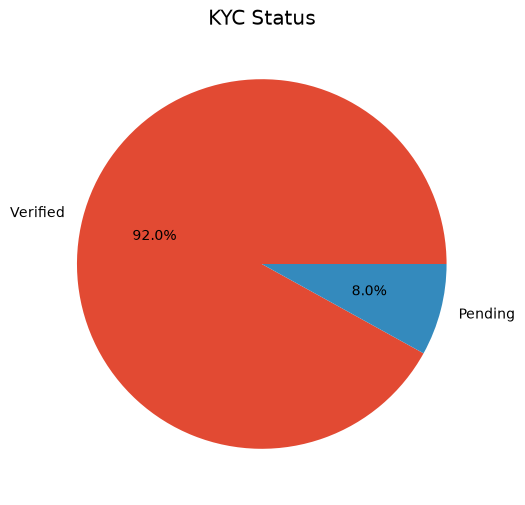

In [18]:
transactions["kyc_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("KYC Status")

plt.show()

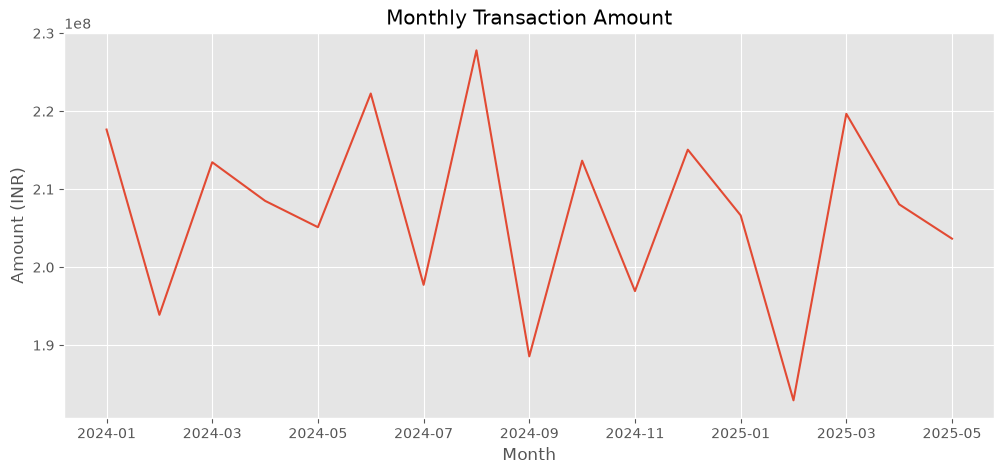

In [19]:
monthly = (
    transactions
    .groupby(transactions["transaction_date"].dt.to_period("M"))
    ["amount_inr"]
    .sum()
)

monthly.index = monthly.index.astype(str)

monthly.plot(
    figsize=(12,5)
)

plt.title("Monthly Transaction Amount")
plt.xlabel("Month")
plt.ylabel("Amount (INR)")

plt.show()

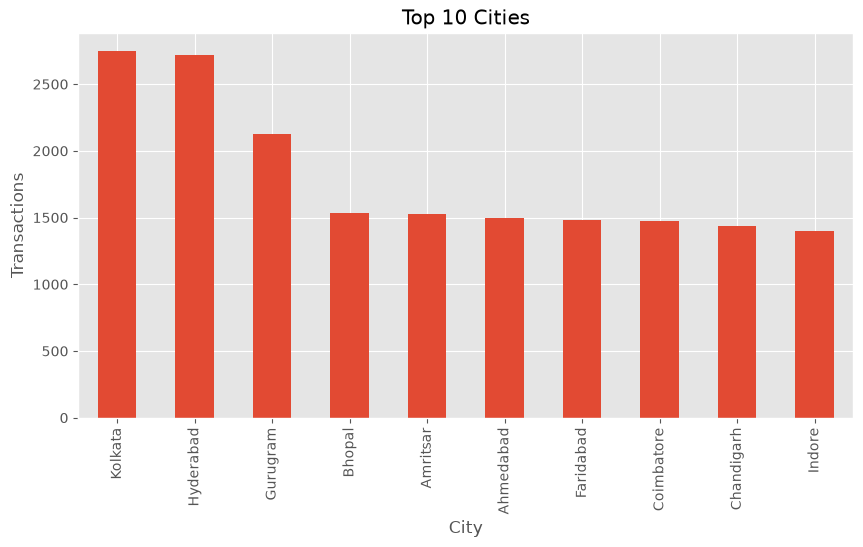

In [20]:
top_city = (
    transactions["city"]
    .value_counts()
    .head(10)
)

top_city.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Cities")
plt.xlabel("City")
plt.ylabel("Transactions")

plt.show()

In [21]:
transactions.groupby(
    "transaction_type"
)["amount_inr"].sum()

transaction_type
Lumpsum       2059821448
Redemption    1244525491
SIP            217233491
Name: amount_inr, dtype: int64

## Key Insights

- SIP transactions contribute a significant share of the total transaction count.
- Investment activity is concentrated in a few major states and cities.
- Digital payment methods account for a large proportion of transactions.
- Most investors have completed KYC verification.
- Monthly transaction amounts show variation across the observed period.